In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/pallavin2541354/traffic-accident/traffic_accident_sample.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/pallavin2541354/traffic-accident/traffic_accident_sample.csv')

In [5]:
df.head()

,Severity,Start_Time,Weather_Condition,Temperature(F),Visibility(mi),Wind_Speed(mph),Humidity(%),Start_Lat,Start_Lng
0,1,2022-03-18 00:00:00,Thunderstorm,42.0,2.6,25.8,89,27.086532,-99.950456
1,1,2022-01-21 08:00:00,Rain,38.6,6.2,19.6,89,35.068476,-98.395084
2,1,2022-07-09 21:00:00,Rain,75.9,3.7,5.4,63,27.453047,-102.344144
3,3,2022-09-03 01:00:00,Snow,41.2,0.9,16.1,35,48.354778,-102.423540
4,3,2022-07-20 03:00:00,Snow,35.4,1.2,23.1,57,48.645316,-75.246890


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Severity           1000 non-null   int64  
 1   Start_Time         1000 non-null   object 
 2   Weather_Condition  1000 non-null   object 
 3   Temperature(F)     1000 non-null   float64
 4   Visibility(mi)     1000 non-null   float64
 5   Wind_Speed(mph)    1000 non-null   float64
 6   Humidity(%)        1000 non-null   int64  
 7   Start_Lat          1000 non-null   float64
 8   Start_Lng          1000 non-null   float64
dtypes: float64(5), int64(2), object(2)
memory usage: 70.4+ KB


In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 9)


In [8]:
df.isnull().sum()

Severity             0
Start_Time           0
Weather_Condition    0
Temperature(F)       0
Visibility(mi)       0
Wind_Speed(mph)      0
Humidity(%)          0
Start_Lat            0
Start_Lng            0
dtype: int64

In [9]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

In [10]:
df['Hour'] = df['Start_Time'].dt.hour

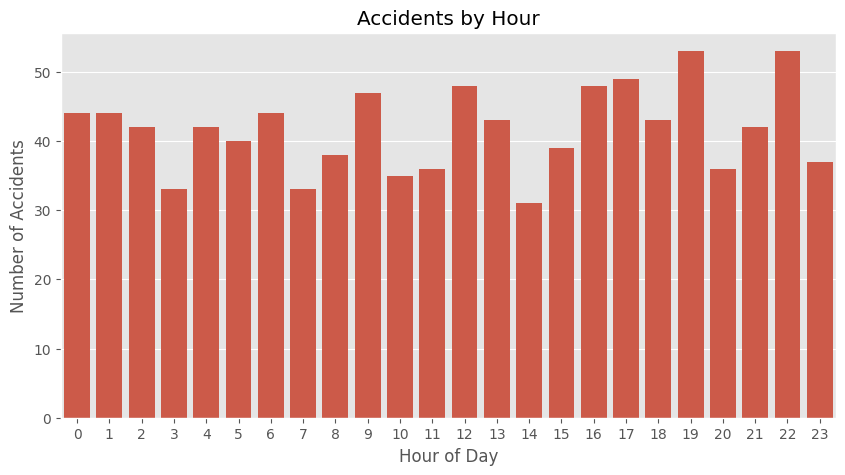

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(x='Hour', data=df)

plt.title("Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")

plt.show()

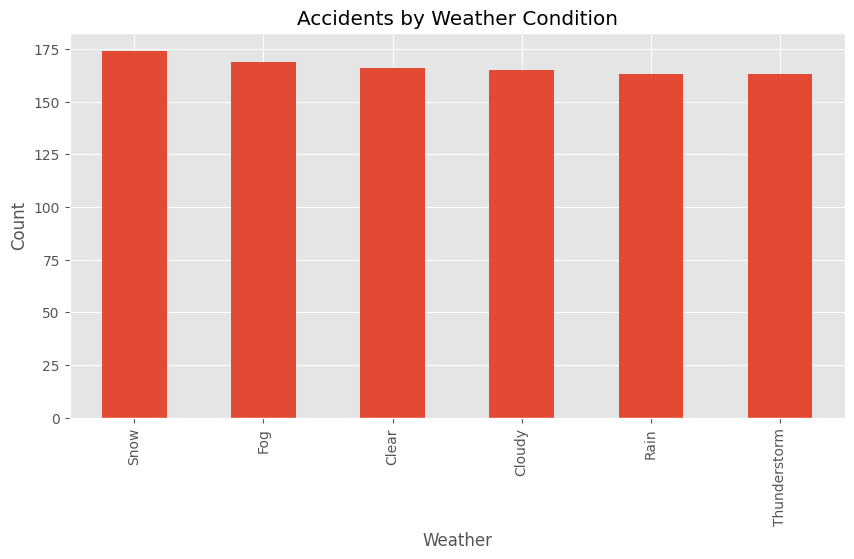

In [12]:
plt.figure(figsize=(10,5))

df['Weather_Condition'].value_counts().plot(kind='bar')

plt.title("Accidents by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Count")

plt.show()

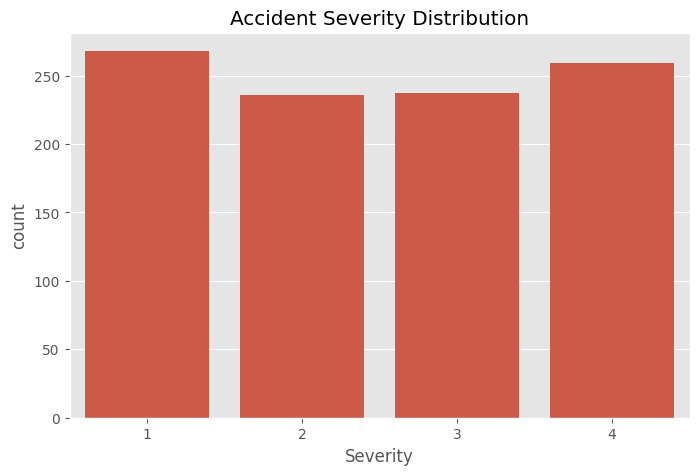

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(x='Severity', data=df)

plt.title("Accident Severity Distribution")

plt.show()

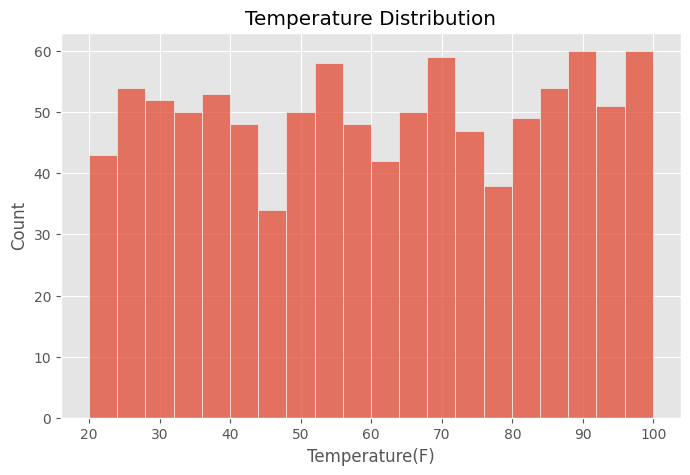

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['Temperature(F)'], bins=20)

plt.title("Temperature Distribution")

plt.show()

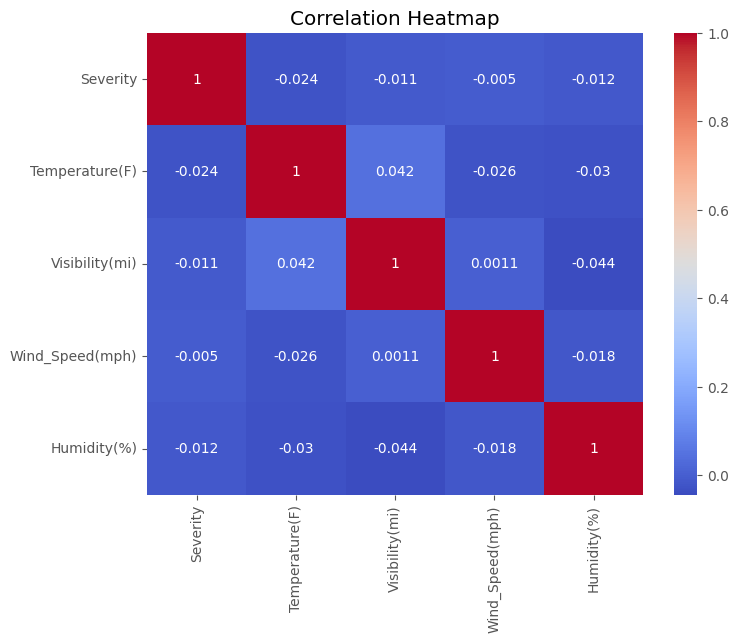

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Severity',
        'Temperature(F)',
        'Visibility(mi)',
        'Wind_Speed(mph)',
        'Humidity(%)']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

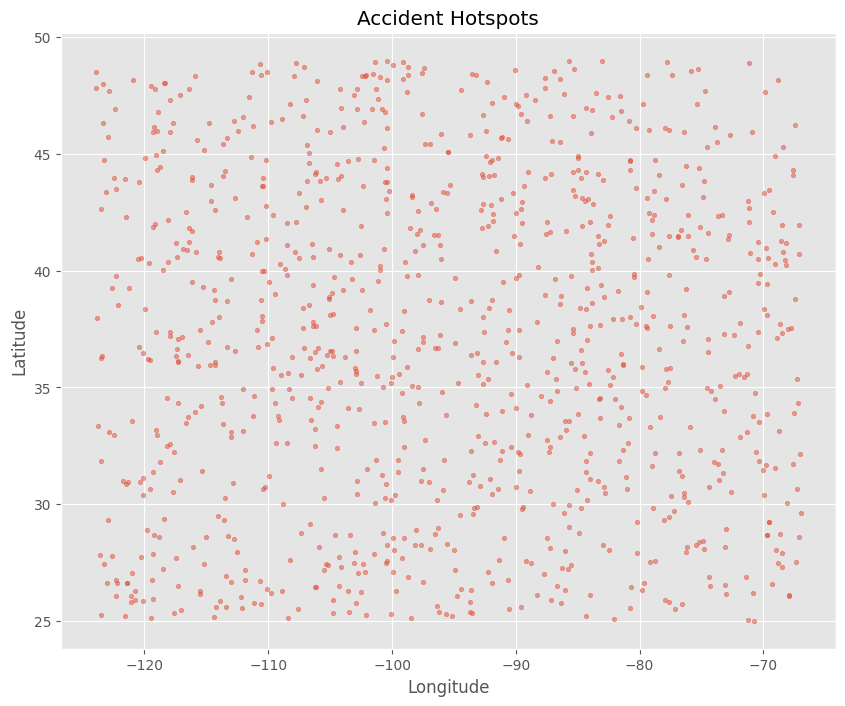

In [16]:
plt.figure(figsize=(10,8))

plt.scatter(
    df['Start_Lng'],
    df['Start_Lat'],
    alpha=0.5,
    s=10
)

plt.title("Accident Hotspots")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()